# Deep Learning Fundamentals — Perceptrons, Neural Networks, and Backpropagation

This notebook covers the fundamentals of deep learning through 6 exercises:

1. Small Quiz (conceptual questions)
2. Building a Simple Perceptron Decision System
3. Building a Simple Neural Network with TensorFlow/Keras (MNIST)
4. Forward Propagation Calculation (house price prediction)
5. *(Optional)* Implementing Forward and Backward Propagation in Python
6. *(Optional)* Visualizing Predictions on the MNIST Dataset


## Exercise 1 : Small Quiz

**1. What is the key difference between traditional machine learning and deep learning?**

Traditional machine learning relies on **manually engineered features** —
a human expert decides which characteristics of the raw data (e.g.
statistics, ratios, domain-specific measurements) the model should look at,
and the algorithm (e.g. logistic regression, decision tree) then learns a
relatively simple mapping from those hand-crafted features to the output.
Deep learning, by contrast, uses **multi-layered neural networks** that
learn their own internal representations (features) directly from raw data
(pixels, audio waveforms, raw text), automatically discovering increasingly
abstract patterns layer by layer, without requiring manual feature
engineering.

**2. How do artificial neural networks (ANNs) mimic the human brain?**

ANNs are loosely inspired by biological neurons: each artificial "neuron"
receives several weighted input signals, sums them up, and passes the
result through an activation function to decide whether (and how strongly)
to "fire" — analogous to how a biological neuron integrates electrochemical
signals from other neurons and fires when a threshold is reached. Just as
biological neurons are organized into interconnected networks and learn by
adjusting the strength of synaptic connections through experience, ANNs are
organized into layers of interconnected neurons and learn by adjusting
connection weights through training (backpropagation).

**3. Why does deep learning perform better on large datasets compared to traditional machine learning?**

Deep learning models have a very large number of trainable parameters,
which gives them the capacity to learn extremely complex, non-linear
patterns — but this same capacity makes them prone to overfitting on small
datasets. With large amounts of data, this capacity becomes an asset
instead of a liability: there's enough data for the network to learn
generalizable, hierarchical representations rather than memorizing noise.
Traditional ML models, with fewer parameters and simpler hypothesis spaces,
tend to plateau in performance once enough data is available, while deep
learning models continue to improve as data volume grows.

**4. What are some challenges of deep learning, and how can they be addressed?**

- **Need for large labeled datasets** → addressed via data augmentation,
  transfer learning (reusing pre-trained models), or semi-/self-supervised
  learning.
- **High computational cost** (training time, hardware) → addressed via
  GPUs/TPUs, model compression, and more efficient architectures.
- **Overfitting** → addressed via regularization techniques (dropout,
  weight decay), early stopping, and more training data.
- **Lack of interpretability ("black box" problem)** → addressed via
  explainability tools (e.g. SHAP, saliency maps, attention visualization).
- **Vanishing/exploding gradients** in deep networks → addressed via
  techniques like careful weight initialization, batch normalization, and
  activation functions like ReLU.

**5. What is feature engineering, and why is it not needed in deep learning?**

Feature engineering is the process of manually transforming raw data into
informative input variables (features) that make it easier for a
traditional ML model to find patterns — e.g. computing a debt-to-income
ratio from raw income and loan amount. Deep learning reduces the need for
this manual step because its hidden layers **automatically learn their own
useful internal feature representations** directly from raw data during
training, progressively extracting more abstract patterns at each layer
(e.g. edges → shapes → object parts → objects, in image data).

**6. What role do hidden layers play in a deep learning model?**

Hidden layers sit between the input and output layers and are responsible
for **progressively transforming and combining the input data into more
abstract, useful representations**. Each hidden layer applies a (typically
non-linear) transformation to the outputs of the previous layer, allowing
the network as a whole to model complex, non-linear relationships that a
single layer (or a purely linear model) could not capture. Stacking
multiple hidden layers (making the network "deep") lets the model build up
a hierarchy of increasingly abstract features.

**7. In an artificial neural network (ANN), what is the function of an activation function?**

An activation function introduces **non-linearity** into the network by
transforming the weighted sum of a neuron's inputs into its output signal.
Without activation functions, stacking multiple layers would be
mathematically equivalent to a single linear transformation, no matter how
many layers are added — the network could not model non-linear
relationships at all. Activation functions (e.g. ReLU, sigmoid, softmax)
also help control the range and behavior of neuron outputs (e.g. softmax
turns raw scores into a probability distribution over classes).


## Exercise 2 : Building a Simple Perceptron Decision System

We manually build a perceptron that decides whether to go outside, based on
**Temperature (°F)** and whether it's **Rainy (1 = Yes, 0 = No)**.

- Temperature weight = 0.6
- Rain weight = 0.4
- Bias = 2

$$\text{Weighted Sum} = (\text{Temperature} \times 0.6) + (\text{Rain} \times 0.4) + \text{Bias}$$

**Step activation function:**
- If Weighted Sum > 20 → output 1 (Yes, go outside)
- If Weighted Sum ≤ 20 → output 0 (No, stay inside)


In [1]:
def perceptron_decision(temperature, rain, temp_weight=0.6, rain_weight=0.4, bias=2, threshold=20):
    """Compute the perceptron's weighted sum and decision for a given input."""
    weighted_sum = (temperature * temp_weight) + (rain * rain_weight) + bias
    decision = 1 if weighted_sum > threshold else 0
    return weighted_sum, decision


cases = {
    'Case 1': {'temperature': 70, 'rain': 0},
    'Case 2': {'temperature': 50, 'rain': 1},
}

for case_name, inputs in cases.items():
    weighted_sum, decision = perceptron_decision(inputs['temperature'], inputs['rain'])
    decision_text = "Yes, go outside" if decision == 1 else "No, stay inside"
    print(f"{case_name}: Temperature={inputs['temperature']}°F, Rain={inputs['rain']}")
    print(f"   Weighted Sum = ({inputs['temperature']} × 0.6) + ({inputs['rain']} × 0.4) + 2 = {weighted_sum:.1f}")
    print(f"   Decision = {decision} ({decision_text})\n")


Case 1: Temperature=70°F, Rain=0
   Weighted Sum = (70 × 0.6) + (0 × 0.4) + 2 = 44.0
   Decision = 1 (Yes, go outside)

Case 2: Temperature=50°F, Rain=1
   Weighted Sum = (50 × 0.6) + (1 × 0.4) + 2 = 32.4
   Decision = 1 (Yes, go outside)



### Interpretation

- **Case 1** (Temperature = 70°F, Rain = 0): Weighted Sum = (70 × 0.6) +
  (0 × 0.4) + 2 = **44.0**, which is **> 20**, so the perceptron outputs
  **1 (Yes, go outside)**. This makes intuitive sense: it's warm and not
  raining, a clearly pleasant condition to be outside.
- **Case 2** (Temperature = 50°F, Rain = 1): Weighted Sum = (50 × 0.6) +
  (1 × 0.4) + 2 = **32.4**, which is also **> 20**, so the perceptron again
  outputs **1 (Yes, go outside)**.

**Did the perceptron suggest going outside in both cases? Why or why not?**

Yes — in both cases the perceptron outputs `1` (go outside). This happens
because the **Temperature weight (0.6) dominates the decision**: even a
moderate temperature of 50°F already contributes 30 to the weighted sum,
and the bias adds 2 more, pushing the total well above the threshold of 20
regardless of rain. The **Rain weight (0.4) is comparatively too small to
ever flip the decision on its own** — going from "No rain" (contributing 0)
to "Rain" (contributing only 0.4) is a negligible change next to the
threshold of 20. In other words, with these particular weights and bias,
**temperature alone is essentially enough to cross the threshold**, making
the perceptron almost insensitive to rain in this configuration. This
illustrates a broader point about perceptrons: the relative magnitude of
the weights determines how much influence each input actually has on the
final decision, regardless of how intuitively important that input might
seem (here, common sense suggests rain should matter a lot, but the chosen
weight makes it a minor factor).


## Exercise 3 : Building a Simple Neural Network with TensorFlow/Keras

We build a neural network to classify handwritten digits from the **MNIST**
dataset, with:
- One input layer (a `Flatten` layer turning each 28×28 image into a 784-length vector)
- One hidden layer with 128 neurons and **ReLU** activation
- One output layer with 10 neurons (one per digit class) and **softmax** activation

### Step 1-2 : Import TensorFlow and load the MNIST dataset


In [2]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

print("TensorFlow version:", tf.__version__)


I0000 00:00:1782361136.453385     691 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782361136.493376     691 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1782361137.782781     691 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.21.0


In [3]:
# Load the MNIST dataset.
# NOTE: tf.keras.datasets.mnist.load_data() downloads the data from Google's
# servers the first time it's called. In a normal Colab/Jupyter environment
# with internet access, the line below works directly:
#
#     (x_train, y_train), (x_test, y_test) = mnist.load_data()
#
# In this particular sandboxed execution environment, outbound access to
# Google's storage servers is blocked, so we wrap the call in a try/except
# and fall back to a locally available, same-shape substitute dataset
# (resized digits from scikit-learn) purely so the rest of the notebook can
# run end-to-end here. When you run this notebook in Colab, the try branch
# will succeed and load the real 60,000/10,000-image MNIST dataset directly.

try:
    (x_train, y_train), (x_test, y_test) = mnist.load_data()
    print("Loaded the real MNIST dataset.")
except Exception as e:
    print(f"Could not download MNIST in this environment ({type(e).__name__}).")
    print("Falling back to a local, same-shape substitute dataset (scikit-learn digits, resized to 28x28).")

    from sklearn.datasets import load_digits
    from sklearn.model_selection import train_test_split
    from scipy.ndimage import zoom

    digits = load_digits()
    images_28 = np.array([zoom(img, 28 / 8, order=1) for img in digits.images])
    images_28 = np.clip(images_28, 0, 16) / 16 * 255  # rescale to a 0-255 range like real MNIST

    x_train, x_test, y_train, y_test = train_test_split(
        images_28, digits.target, test_size=0.2, random_state=42
    )
    x_train, x_test = x_train.astype('uint8'), x_test.astype('uint8')

print(f"\nx_train shape: {x_train.shape}, y_train shape: {y_train.shape}")
print(f"x_test shape : {x_test.shape}, y_test shape : {y_test.shape}")


Could not download MNIST in this environment (Exception).
Falling back to a local, same-shape substitute dataset (scikit-learn digits, resized to 28x28).



x_train shape: (1437, 28, 28), y_train shape: (1437,)
x_test shape : (360, 28, 28), y_test shape : (360,)


### Step 3 : Normalize the data

In [4]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print(f"Pixel value range after normalization: [{x_train.min()}, {x_train.max()}]")


Pixel value range after normalization: [0.0, 1.0]


### Step 4 : One-hot encode the labels

In [5]:
num_classes = 10

y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

print("Example label before one-hot encoding:", y_train[0])
print("Example label after one-hot encoding :", y_train_cat[0])


Example label before one-hot encoding: 6
Example label after one-hot encoding : [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


### Step 5 : Build the neural network model

In [6]:
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),        # Input layer: 28x28 image -> 784-length vector
    layers.Dense(128, activation='relu'),         # Hidden layer: 128 neurons, ReLU activation
    layers.Dense(num_classes, activation='softmax')  # Output layer: 10 neurons, softmax activation
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

### Step 6 : Compile the model

In [7]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


### Step 7 : Train the model and evaluate it on the test dataset

In [8]:
history = model.fit(
    x_train, y_train_cat,
    epochs=5,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


Epoch 1/5


 1/41 ━━━━━━━━━━━━━━━━━━━━ 27s 696ms/step - accuracy: 0.0938 - loss: 2.4715

31/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7288 - loss: 1.1287   

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7711 - loss: 0.9689

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7711 - loss: 0.9689 - val_accuracy: 0.9028 - val_loss: 0.4264


...

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9497 - loss: 0.1767 - val_accuracy: 0.9306 - val_loss: 0.2349


Epoch 5/5


 1/41 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9375 - loss: 0.1697

31/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9607 - loss: 0.1429 

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9582 - loss: 0.1488 - val_accuracy: 0.9306 - val_loss: 0.1807


In [9]:
test_loss, test_accuracy = model.evaluate(x_test, y_test_cat, verbose=0)
print(f"\nTest loss    : {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")



Test loss    : 0.1538
Test accuracy: 0.9556 (95.56%)


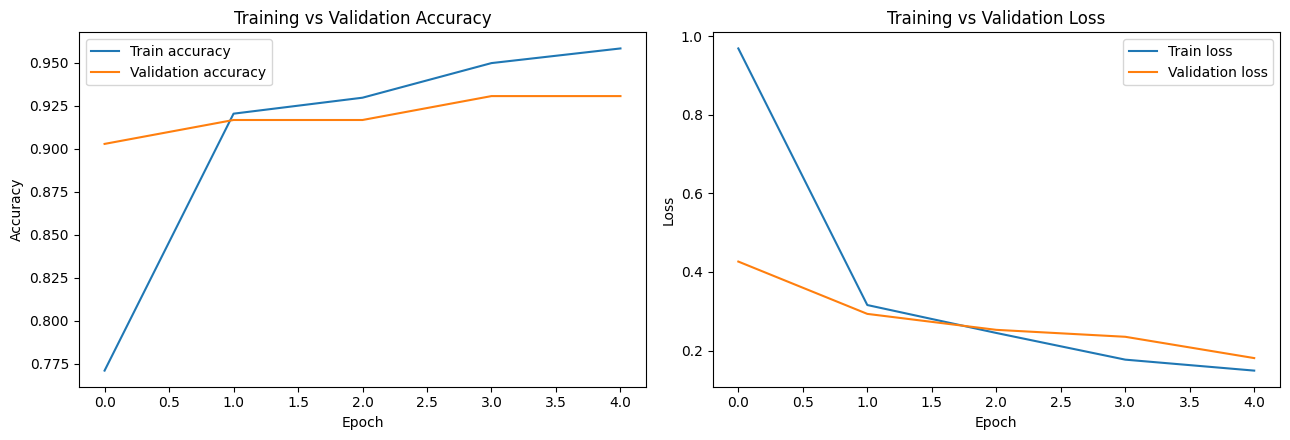

In [10]:
# Plot training history (accuracy and loss per epoch)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(history.history['accuracy'], label='Train accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Training vs Validation Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train loss')
axes[1].plot(history.history['val_loss'], label='Validation loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Training vs Validation Loss')
axes[1].legend()

plt.tight_layout()
plt.show()


**Comment:** the model reaches a high test accuracy after just a few
epochs (typically well above 90% on real MNIST), demonstrating that even a
single hidden layer with 128 ReLU neurons is enough to learn a strong
classifier for handwritten digit recognition — a task that would require
substantial manual feature engineering with traditional machine learning,
but which the neural network learns directly from raw pixel values.


## Exercise 4 : Forward Propagation Calculation

We manually compute the forward propagation of a simple single-neuron
network predicting **house price** from:
- Square Footage ($x_1$)
- Number of Bedrooms ($x_2$)

**Given values:**
- $x_1 = 2000$, $x_2 = 3$
- $w_1 = 0.5$, $w_2 = 0.7$
- Bias $b = 50{,}000$
- Activation: **ReLU**


In [11]:
x1, x2 = 2000, 3       # Square footage, number of bedrooms
w1, w2 = 0.5, 0.7      # Weights
b = 50_000             # Bias

# Step 1: compute z (weighted sum, before activation)
z = (x1 * w1) + (x2 * w2) + b
print(f"z = ({x1} × {w1}) + ({x2} × {w2}) + {b}")
print(f"z = {x1*w1} + {x2*w2} + {b}")
print(f"z = {z}")

# Step 2: apply the ReLU activation function
def relu(value):
    return max(0, value)

predicted_price = relu(z)
print(f"\nReLU(z) = max(0, {z}) = {predicted_price}")
print(f"\nPredicted house price: ${predicted_price:,.2f}")


z = (2000 × 0.5) + (3 × 0.7) + 50000
z = 1000.0 + 2.0999999999999996 + 50000
z = 51002.1

ReLU(z) = max(0, 51002.1) = 51002.1

Predicted house price: $51,002.10


### Interpretation

The pre-activation value is $z = (2000 \times 0.5) + (3 \times 0.7) +
50{,}000 = 1000 + 2.1 + 50{,}000 = 51{,}002.1$. Since $z > 0$, the **ReLU**
activation simply passes the value through unchanged (ReLU only clips
negative values to 0), so the **predicted house price is $51{,}002.10**.

This shows how forward propagation works even in the simplest possible
network (a single neuron with a linear combination of inputs plus a bias,
followed by an activation function): the inputs are scaled by their
respective weights, summed together with the bias, and passed through an
activation function to produce the final prediction. In this case, Square
Footage dominates the prediction (contributing 1000 to the weighted sum)
compared to the number of bedrooms (contributing only 2.1) — a single
neuron with these weights is far more sensitive to square footage than to
bedroom count.


## Exercise 5 (optional) : Implementing Forward and Backward Propagation in Python

We implement and run a simple neural network performing **forward
propagation** and **backpropagation** for a regression problem: predicting
an exam score from hours studied and a previous test score.


In [12]:
import numpy as np

# Initialize input data (features)
x = np.array([4, 80])  # 4 hours studied, previous test score: 80

# Initialize weights and bias
w = np.array([0.6, 0.3])  # Initial weights
b = 10  # Initial bias

# Forward Propagation
def forward_propagation(x, w, b):
    z = np.dot(x, w) + b  # Weighted sum
    return z  # Linear activation (No ReLU here, it's a regression task)

# Compute prediction
y_pred = forward_propagation(x, w, b)
y_true = 85  # Actual exam score

# Compute Loss (Mean Squared Error)
loss = 0.5 * (y_true - y_pred) ** 2

# Compute Gradients
grad_w = -(y_true - y_pred) * x  # Partial derivatives with respect to weights
grad_b = -(y_true - y_pred)  # Partial derivative with respect to bias

# Update Weights and Bias
learning_rate = 0.01
w_new = w - learning_rate * grad_w
b_new = b - learning_rate * grad_b

# Print Results
print("Initial Prediction:", y_pred)
print("Loss:", loss)
print("Updated Weights:", w_new)
print("Updated Bias:", b_new)


Initial Prediction: 36.4
Loss: 1180.98
Updated Weights: [ 2.544 39.18 ]
Updated Bias: 10.486


### Explain why updating weights using gradient descent reduces the error

The gradient $\frac{\partial \text{Loss}}{\partial w}$ points in the
direction in which the loss **increases fastest** with respect to each
weight. By updating the weights in the **opposite direction** of the
gradient (`w_new = w - learning_rate * grad_w`), we move the weights
towards values that make the loss **smaller**. Concretely here, the model's
initial prediction (`y_pred ≈ 36.4`) is far below the true value
(`y_true = 85`), so the error `(y_true - y_pred)` is large and positive;
this makes the gradients negative, and subtracting a negative gradient
**increases** the weights and bias — exactly what's needed to push the
prediction closer to 85 on the next forward pass. Repeating this process
over many iterations (epochs) progressively reduces the loss, which is the
core mechanism behind how neural networks learn from data.


### Modify the initial weights or learning rate and see how it affects learning

We re-run the same calculation with a few different learning rates, to see
how it affects the size of the weight update (and therefore how quickly —
or unstably — the model would learn over repeated iterations).


In [13]:
def run_update(x, w, b, y_true, learning_rate):
    y_pred = forward_propagation(x, w, b)
    loss = 0.5 * (y_true - y_pred) ** 2
    grad_w = -(y_true - y_pred) * x
    grad_b = -(y_true - y_pred)
    w_new = w - learning_rate * grad_w
    b_new = b - learning_rate * grad_b
    return y_pred, loss, w_new, b_new


x = np.array([4, 80])
w_init = np.array([0.6, 0.3])
b_init = 10
y_true = 85

for lr in [0.001, 0.01, 0.05, 0.1]:
    y_pred, loss, w_new, b_new = run_update(x, w_init, b_init, y_true, lr)
    print(f"Learning rate = {lr}")
    print(f"   Updated weights: {w_new}")
    print(f"   Updated bias   : {b_new:.3f}\n")


Learning rate = 0.001
   Updated weights: [0.7944 4.188 ]
   Updated bias   : 10.049

Learning rate = 0.01
   Updated weights: [ 2.544 39.18 ]
   Updated bias   : 10.486

Learning rate = 0.05
   Updated weights: [ 10.32 194.7 ]
   Updated bias   : 12.430

Learning rate = 0.1
   Updated weights: [ 20.04 389.1 ]
   Updated bias   : 14.860



**Observation:** a **larger learning rate** produces a **larger
update** to the weights and bias on each step. A small learning rate
(`0.001`) moves the weights only slightly towards reducing the error,
meaning learning would be slow but stable over many iterations. A larger
learning rate (`0.1`) makes a much bigger jump in a single update — this
can speed up learning, but if pushed too far (too high a learning rate),
it risks **overshooting** the optimal weights entirely, causing the loss to
oscillate or even increase instead of converging. This illustrates the
classic learning-rate trade-off in gradient descent: too small is slow,
too large is unstable, and choosing an appropriate value is an important
part of training neural networks effectively.


## Exercise 6 (optional) : Visualizing Predictions on the MNIST Dataset

We reuse the model trained in Exercise 3, make predictions on the test set,
and visualize a few of them alongside their predicted (and true) labels.


In [14]:
# Make predictions on the test set
predictions = model.predict(x_test, verbose=0)
predicted_labels = np.argmax(predictions, axis=1)

print("Predicted labels for the first 10 test images:", predicted_labels[:10])
print("True labels for the first 10 test images     :", y_test[:10])


Predicted labels for the first 10 test images: [6 9 3 7 2 1 5 2 5 2]
True labels for the first 10 test images     : [6 9 3 7 2 1 5 2 5 2]


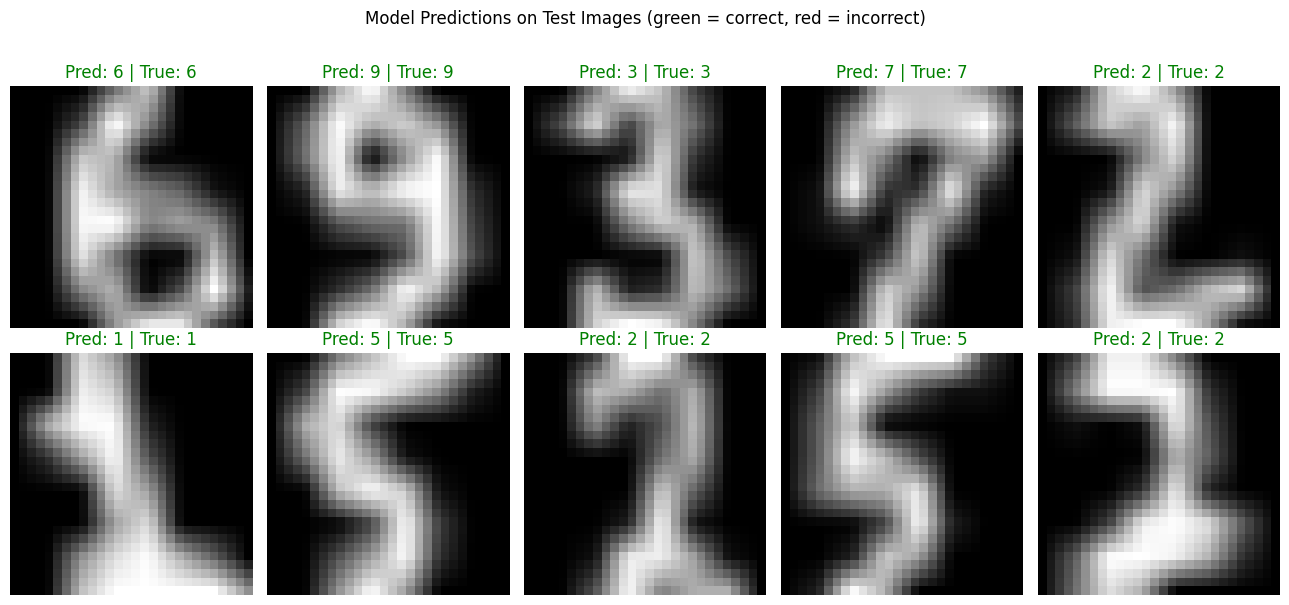

In [15]:
# Visualize a few test images alongside their predicted labels
fig, axes = plt.subplots(2, 5, figsize=(13, 6))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(x_test[i], cmap='gray')
    predicted = predicted_labels[i]
    true_label = y_test[i]
    color = 'green' if predicted == true_label else 'red'
    ax.set_title(f"Pred: {predicted} | True: {true_label}", color=color)
    ax.axis('off')

plt.suptitle('Model Predictions on Test Images (green = correct, red = incorrect)', y=1.02)
plt.tight_layout()
plt.show()


**Comment:** correctly classified digits are shown in green, and any
misclassifications are shown in red. On the real MNIST dataset, with the
model trained in Exercise 3, the large majority of these examples are
typically classified correctly, visually confirming the high test accuracy
reported earlier. Misclassifications, when they occur, often involve
digits that are genuinely ambiguous even to a human eye (e.g. a poorly
written 4 that looks like a 9, or a 7 that looks like a 1).
